# Séparer croissance, rendement et prévision

Ce parcours commence par un calcul que l’on peut vérifier à la main, puis lit les résultats du projet. Il n’exécute aucun téléchargement. Les analyses complètes se lancent avec la commande `crb run`.

In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

if not Path("config/protocol.json").exists():
    os.chdir("..")
assert Path("config/protocol.json").exists(), "Ouvrir ce notebook dans le dépôt"

## Un exemple à vérifier à la main

In [2]:
from crb.model import geometric, real_return

print("Après −20 % et +25 %, croissance composée", round(float(geometric([-0.20, 0.25])) * 100, 2), "%")
print(
    "Après +20 % nominal et +10 % d’inflation, gain réel", round(float(real_return(0.20, 0.10)) * 100, 2), "%"
)

Après −20 % et +25 %, croissance composée 0.0 %
Après +20 % nominal et +10 % d’inflation, gain réel 9.09 %


Une moyenne de pourcentages ne décrit pas toujours le capital final. Le rendement réel utilise aussi un quotient exact.

## Les observations de l’étude

Les colonnes et leurs unités sont expliquées dans [le guide des résultats](../docs/RESULTATS.md). Les proportions sont enregistrées en fractions. Une valeur de 0,10 signifie 10 %.

In [3]:
results = pd.read_csv("results/tables/period_correlations.csv")
results.head(12)

,start_year,end_year,countries,years,pearson_geometric,spearman_geometric,pearson_arithmetic
0,1950,2020,16,71,-0.206473,-0.211765,-0.073491
1,1900,2011,15,112,-0.173862,-0.153571,0.015571
2,1900,1949,15,50,0.384471,0.403571,0.047828
3,1950,1984,16,35,0.025734,-0.047059,0.068585
4,1985,2020,16,36,0.226591,0.114706,0.218264
5,2000,2020,16,21,0.544580,0.520588,0.524854


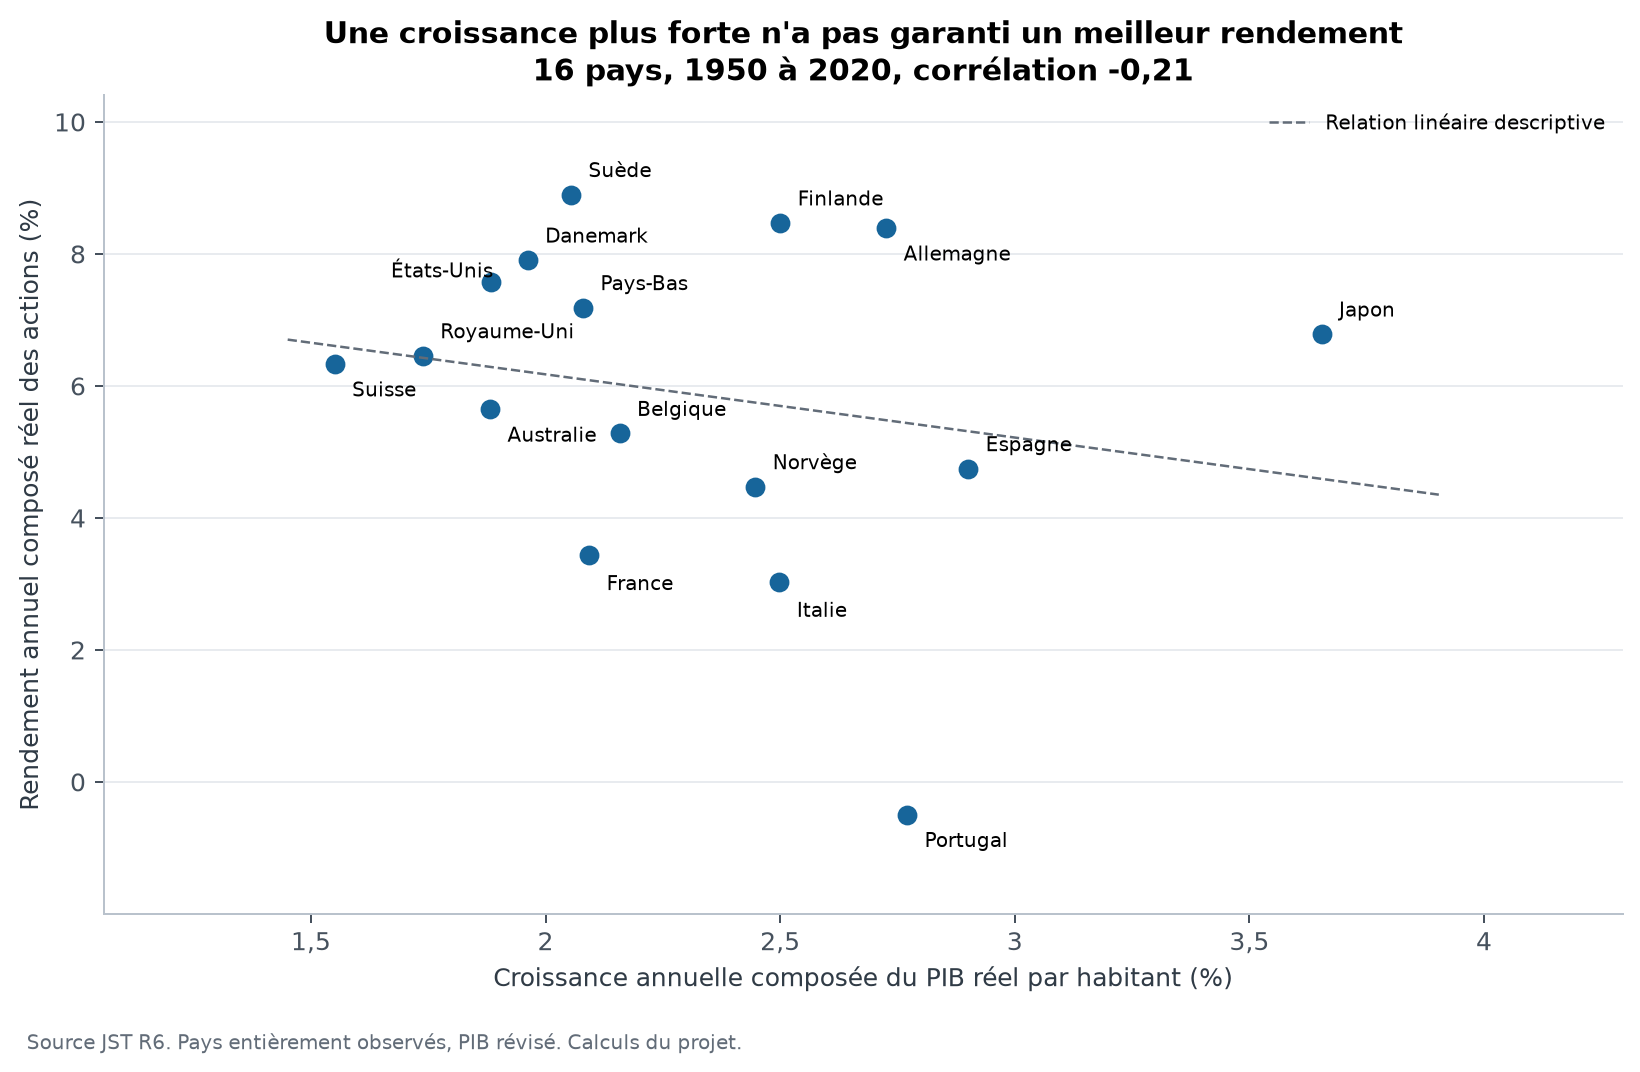

In [4]:
display(Image(filename="results/figures/croissance_et_rendement.png", width=900))

## Vérifier une autre hypothèse

Le tableau suivant montre une analyse complémentaire. Comparer les périodes, les dénominateurs et les paramètres avant de comparer les résultats.

In [5]:
pd.read_csv("results/tables/forecast_scores.csv").head(18)

,iso,country,observations,oos_r2,rmse_model,rmse_benchmark
0,ALL,Ensemble des pays,576,-0.005108,0.251342,0.250703
1,AUS,Australia,36,0.007282,0.172005,0.172635
2,BEL,Belgium,36,0.019139,0.243422,0.245785
3,CHE,Switzerland,36,-0.009310,0.216911,0.215908
4,DEU,Germany,36,-0.065751,0.241732,0.234157
5,DNK,Denmark,36,-0.051682,0.212916,0.207619
6,ESP,Spain,36,0.009256,0.266732,0.267975
7,FIN,Finland,36,0.011116,0.393158,0.395361
8,FRA,France,36,0.075645,0.235483,0.244929
9,GBR,UK,36,-0.069450,0.153479,0.148412


## Ce que l’on peut conclure

Revenir à [l’article](../ARTICLE.md) pour lire les conclusions et les limites. Les exemples du notebook ne remplacent pas les contrôles de chronologie et d’incertitude du paquet. Le [protocole](../docs/PROTOCOLE.md) indique ce qui était fixé avant le calcul complet.